In [1]:
# Fix for scikit-learn OpenBLAS error
import os
os.environ['OMP_NUM_THREADS'] = '1'

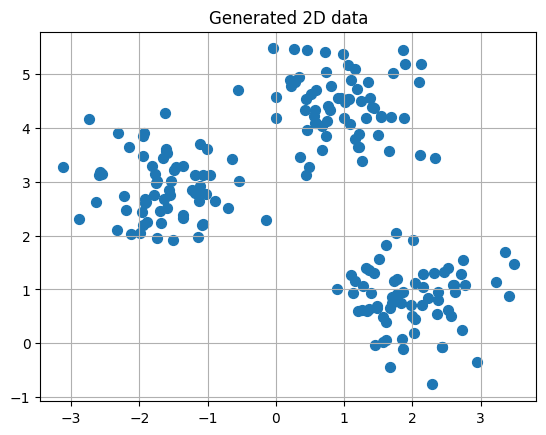

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs 
# Generate synthetic 2D data 
X, y = make_blobs(n_samples=200, centers=3, cluster_std=0.60, random_state=0) 
plt.scatter(X[:, 0], X[:, 1], s=50) 
plt.title("Generated 2D data") 
plt.grid(True) 
plt.show()

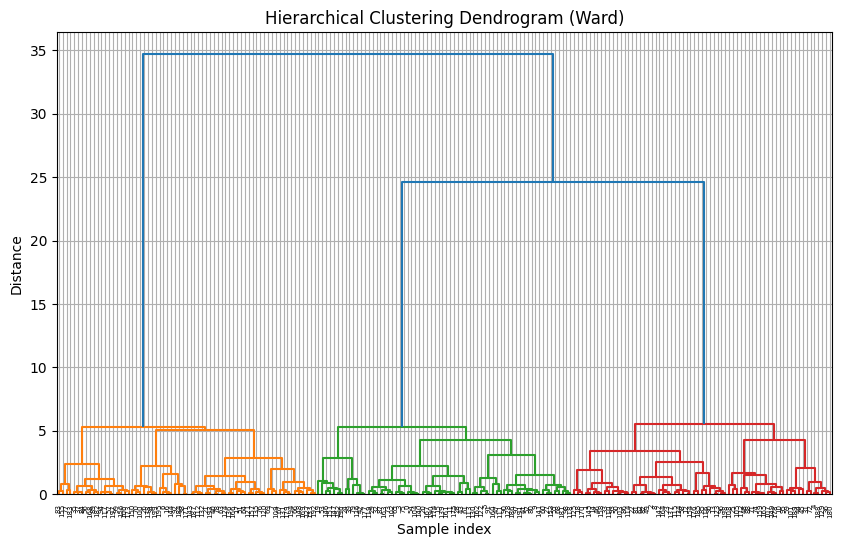

In [3]:
from scipy.cluster.hierarchy import dendrogram, linkage 
from sklearn.cluster import AgglomerativeClustering 
# Compute linkage matrix (use 'ward', 'single', 'complete', or 'average') 
linked = linkage(X, method='ward') 
# Plot dendrogram 
plt.figure(figsize=(10, 6)) 
dendrogram(linked) 
plt.title("Hierarchical Clustering Dendrogram (Ward)") 
plt.xlabel("Sample index") 
plt.ylabel("Distance") 
plt.grid(True) 
plt.show() 

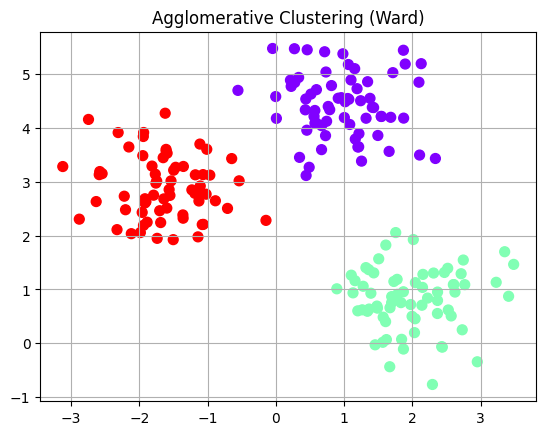

In [4]:
# Fit agglomerative clustering 
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward') 
labels = cluster.fit_predict(X) 
# Plot clustering result 
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', s=50) 
plt.title("Agglomerative Clustering (Ward)") 
plt.grid(True) 
plt.show()

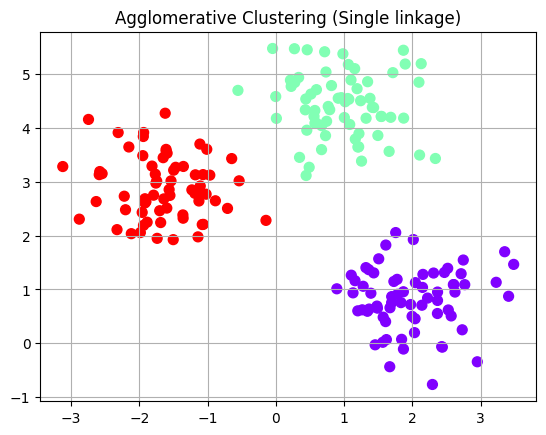

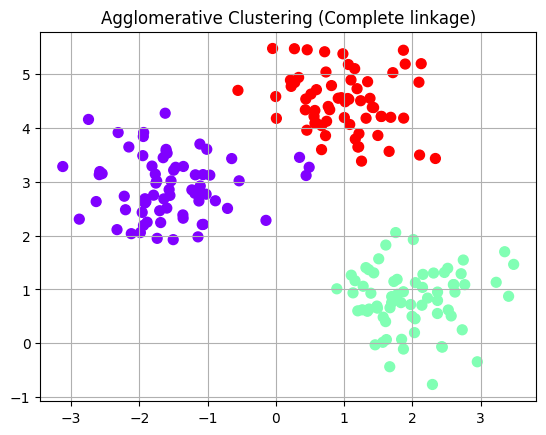

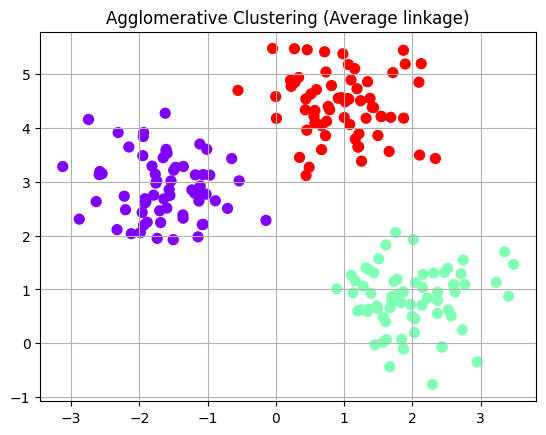

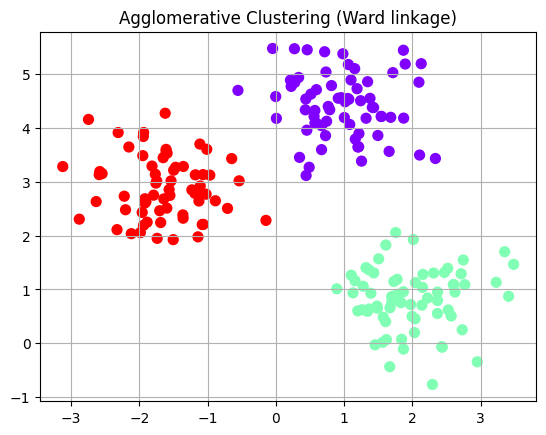

In [5]:
methods = ['single', 'complete', 'average', 'ward'] 
for method in methods: 
    cluster = AgglomerativeClustering(n_clusters=3, linkage=method) 
    labels = cluster.fit_predict(X) 
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', s=50) 
    plt.title(f"Agglomerative Clustering ({method.capitalize()} linkage)") 
    plt.grid(True) 
    plt.show()

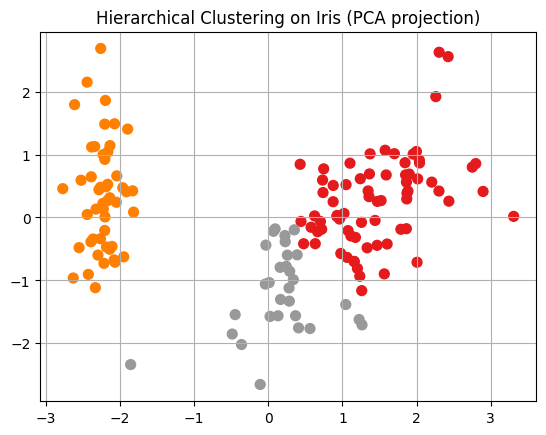

In [6]:
from sklearn.datasets import load_iris 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
# Load and scale data 
iris = load_iris() 
X = iris.data 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 
# PCA for 2D projection 
pca = PCA(n_components=2) 
X_pca = pca.fit_transform(X_scaled) 
# Apply clustering 
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward') 
labels = cluster.fit_predict(X_scaled) 
# Plot clustering in 2D 
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1', s=50) 
plt.title("Hierarchical Clustering on Iris (PCA projection)") 
plt.grid(True) 
plt.show()

Part 7: Going Further 
• Use fcluster from scipy.cluster.hierarchy to cut the dendrogram at a specific distance. 
• Visualize clusters with noise or varying densities. 
• Compare with DBSCAN or K-Means on the same datasets. 
• Test it on high-dimensional data using dimensionality reduction (e.g., PCA or t-SNE).

In [7]:
from sklearn.manifold import TSNE

# Load Iris (4D data)
iris = load_iris()
X_hd = iris.data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_hd)

# Cluster in original space
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = cluster.fit_predict(X_scaled)

# Reduce with PCA and t-SNE
X_pca = PCA(n_components=2).fit_transform(X_scaled)
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='Set1', s=50)
axes[0].set_title("PCA Projection")
axes[0].grid(True)

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels, cmap='Set1', s=50)
axes[1].set_title("t-SNE Projection")
axes[1].grid(True)

plt.tight_layout()
plt.show()

AttributeError: 'NoneType' object has no attribute 'split'

## 4. High-Dimensional Data with t-SNE
Use t-SNE to reduce high-dimensional data to 2D for visualization while preserving local structure.

In [10]:
from sklearn.cluster import DBSCAN, KMeans

# Apply three algorithms
kmeans = KMeans(n_clusters=3, random_state=42)
dbscan = DBSCAN(eps=0.8, min_samples=5)
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')

labels_km = kmeans.fit_predict(X_noisy)
labels_db = dbscan.fit_predict(X_noisy)
labels_hc = hierarchical.fit_predict(X_noisy)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(X_noisy[:, 0], X_noisy[:, 1], c=labels_km, cmap='rainbow', s=50)
axes[0].set_title("K-Means")
axes[0].grid(True)

axes[1].scatter(X_noisy[:, 0], X_noisy[:, 1], c=labels_db, cmap='rainbow', s=50)
axes[1].set_title("DBSCAN (noise = -1)")
axes[1].grid(True)

axes[2].scatter(X_noisy[:, 0], X_noisy[:, 1], c=labels_hc, cmap='rainbow', s=50)
axes[2].set_title("Hierarchical")
axes[2].grid(True)

plt.tight_layout()
plt.show()

C:\Users\ramse\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


AttributeError: 'NoneType' object has no attribute 'split'

## 3. Compare with DBSCAN and K-Means
Compare three clustering algorithms on same data to observe different behaviors and strengths.

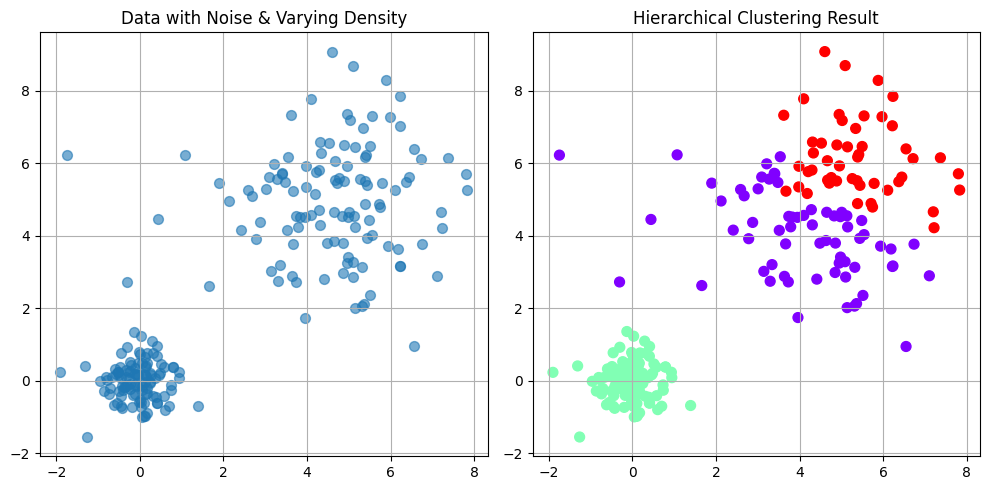

In [9]:
# Generate data with varying densities and noise
X1, _ = make_blobs(n_samples=100, centers=[[0, 0]], cluster_std=0.5, random_state=42)
X2, _ = make_blobs(n_samples=100, centers=[[5, 5]], cluster_std=1.5, random_state=42)
noise = np.random.uniform(-2, 7, size=(20, 2))
X_noisy = np.vstack([X1, X2, noise])

cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = cluster.fit_predict(X_noisy)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_noisy[:, 0], X_noisy[:, 1], s=50, alpha=0.6)
plt.title("Data with Noise & Varying Density")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X_noisy[:, 0], X_noisy[:, 1], c=labels, cmap='rainbow', s=50)
plt.title("Hierarchical Clustering Result")
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. Clusters with Noise and Varying Densities
Generate data with different cluster densities and noise to test hierarchical clustering robustness.

ValueError: 'c' argument has 200 elements, which is inconsistent with 'x' and 'y' with size 150.

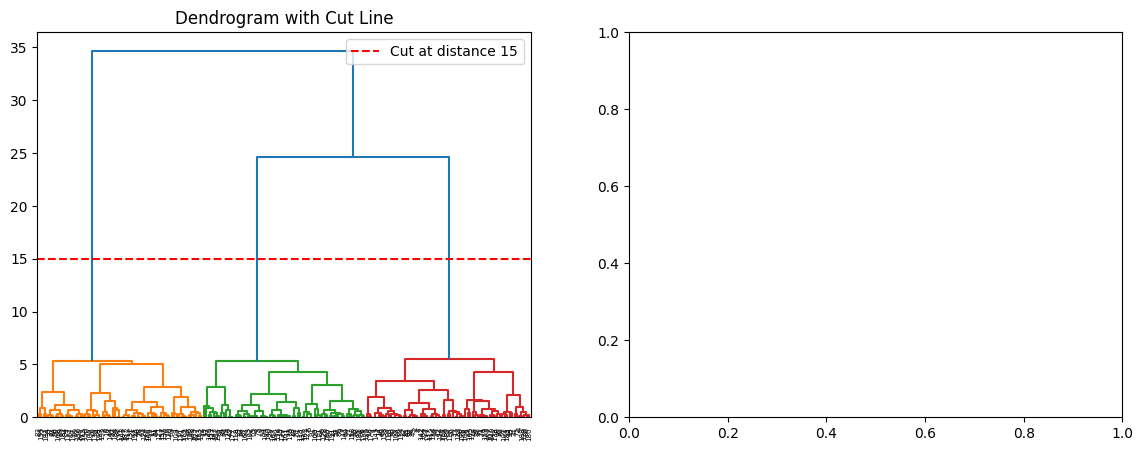

In [8]:
from scipy.cluster.hierarchy import fcluster

# Cut dendrogram at distance threshold
labels_fcluster = fcluster(linked, t=15, criterion='distance')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
dendrogram(linked, ax=ax1)
ax1.axhline(y=15, color='r', linestyle='--', label='Cut at distance 15')
ax1.set_title("Dendrogram with Cut Line")
ax1.legend()

ax2.scatter(X[:, 0], X[:, 1], c=labels_fcluster, cmap='rainbow', s=50)
ax2.set_title(f"Clusters from fcluster (n={labels_fcluster.max()})")
plt.tight_layout()
plt.show()

## 1. Cutting Dendrogram with fcluster
Cut dendrogram at specific distance to form clusters automatically without specifying cluster count.

### Key Observations:

**PCA vs t-SNE:**
- **PCA** (linear): Preserves global structure, faster, explains variance
- **t-SNE** (non-linear): Better at preserving local neighborhoods, shows clearer cluster separation

**Why cluster in high-dimensional space?**
- Clustering is performed in the original 64D space for better distance calculations
- Dimensionality reduction (PCA/t-SNE) is **only for visualization**
- Reducing before clustering can lose important information!

In [ ]:
# Step 5: Evaluate clustering quality
from sklearn.metrics import adjusted_rand_score, silhouette_score, homogeneity_score

# Compare with true labels
ari = adjusted_rand_score(y_true, labels_hc)
homogeneity = homogeneity_score(y_true, labels_hc)

# Silhouette score (measure of cluster quality)
silhouette_avg = silhouette_score(X_scaled, labels_hc)

print("="*60)
print("CLUSTERING EVALUATION METRICS")
print("="*60)
print(f"Adjusted Rand Index (ARI): {ari:.3f}")
print(f"  → Measures similarity with true labels (1.0 = perfect)")
print()
print(f"Homogeneity Score: {homogeneity:.3f}")
print(f"  → Each cluster contains only members of a single class")
print()
print(f"Silhouette Score: {silhouette_avg:.3f}")
print(f"  → Measures how well-separated clusters are (-1 to 1)")
print("="*60)

In [ ]:
# Step 4: Visualize Clustering Results

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Plot 1: PCA projection with hierarchical cluster labels
scatter1 = axes[0, 0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_hc, 
                              cmap='tab10', s=30, alpha=0.7)
axes[0, 0].set_title("PCA Projection - Hierarchical Clusters", fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel("PC1")
axes[0, 0].set_ylabel("PC2")
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label='Cluster ID')

# Plot 2: PCA projection with true labels
scatter2 = axes[0, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, 
                              cmap='tab10', s=30, alpha=0.7)
axes[0, 1].set_title("PCA Projection - True Labels", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("PC1")
axes[0, 1].set_ylabel("PC2")
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0, 1], label='True Digit')

# Plot 3: t-SNE projection with hierarchical cluster labels
scatter3 = axes[1, 0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_hc, 
                              cmap='tab10', s=30, alpha=0.7)
axes[1, 0].set_title("t-SNE Projection - Hierarchical Clusters", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("t-SNE 1")
axes[1, 0].set_ylabel("t-SNE 2")
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter3, ax=axes[1, 0], label='Cluster ID')

# Plot 4: t-SNE projection with true labels
scatter4 = axes[1, 1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_true, 
                              cmap='tab10', s=30, alpha=0.7)
axes[1, 1].set_title("t-SNE Projection - True Labels", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("t-SNE 1")
axes[1, 1].set_ylabel("t-SNE 2")
axes[1, 1].grid(True, alpha=0.3)
plt.colorbar(scatter4, ax=axes[1, 1], label='True Digit')

plt.tight_layout()
plt.show()

In [ ]:
# Step 3: Dimensionality Reduction for Visualization

# PCA: Linear dimensionality reduction (preserves global structure)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}")

# t-SNE: Non-linear dimensionality reduction (preserves local structure)
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE transformation completed")

In [ ]:
# Step 1: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_high)

# Step 2: Perform hierarchical clustering in 64D space
n_clusters = 10  # We know there are 10 digit classes
hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_hc = hierarchical.fit_predict(X_scaled)

print(f"Clustering completed with {n_clusters} clusters")
print(f"Cluster distribution: {np.bincount(labels_hc)}")

In [ ]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt
import numpy as np

# Load the Digits dataset (1797 samples, 64 features)
digits = load_digits()
X_high = digits.data  # 64-dimensional (8x8 pixel images)
y_true = digits.target  # True labels (0-9)

print(f"Dataset shape: {X_high.shape}")
print(f"Number of features: {X_high.shape[1]}")
print(f"Number of samples: {X_high.shape[0]}")
print(f"True classes: {np.unique(y_true)}")

# Visualize some sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y_true[i]}")
    ax.axis('off')
plt.suptitle("Sample Digits from Dataset", fontsize=14)
plt.tight_layout()
plt.show()

## High-Dimensional Clustering: Digits Dataset (64D → 2D)

We'll use the **Digits dataset** with 64 features (8x8 pixel images) to demonstrate:
1. Hierarchical clustering in original high-dimensional space
2. Visualization using PCA (linear) and t-SNE (non-linear) projections
3. Compare cluster assignments with true labels